# Revisión del doble modo de estrella RRd y aRRd

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
ruta_catalogo = Path(
    "../data/interim/catalogo_maestro.csv"
)

catalogo = pd.read_csv(
    ruta_catalogo,
    dtype={
        "observacion_id": "string",
        "star_id": "string",
        "proyecto_origen": "string",
        "region_origen": "string",
        "subtipo_rrlyrae": "string",
        "ruta_curva": "string",
        "archivo_periodos": "string",
    },
)

doble_modo = (
    catalogo[
        catalogo["subtipo_rrlyrae"]
        .isin(["RRd", "aRRd"])
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"Filas del catálogo: {len(catalogo):,}")
print(
    "Observaciones RRd/aRRd: "
    f"{len(doble_modo):,}"
)
print(
    "Estrellas físicas RRd/aRRd: "
    f"{doble_modo['star_id_base'].nunique():,}\n"
)

print(
    doble_modo
    .groupby(
        [
            "proyecto_origen",
            "region_origen",
            "subtipo_rrlyrae",
        ]
    )
    .size()
    .rename("cantidad")
    .to_string()
)

C:\Users\adanm\AppData\Local\Temp\ipykernel_6140\2460186806.py:5: DtypeWarning: Columns (0: transicion) have mixed types. Specify dtype option on import or set low_memory=False.
  catalogo = pd.read_csv(


Filas del catálogo: 104,008
Observaciones RRd/aRRd: 3,387
Estrellas físicas RRd/aRRd: 2,286

proyecto_origen  region_origen  subtipo_rrlyrae
OGLE-III         BLG            RRd                  60
                 LMC            RRd                 940
                 SMC            RRd                 257
OGLE-IV          BLG            RRd                 105
                 LMC            RRd                1454
                                aRRd                 20
                 SMC            RRd                 549
                                aRRd                  2


In [3]:
ruta_periodos = Path("../data/raw/periods")

registros_doble_modo = []

for archivo in sorted(ruta_periodos.glob("*.dat")):
    partes = archivo.stem.split("-")
    proyecto = f"{partes[0]}-{partes[1]}"
    region = partes[2]
    subtipo = partes[3]

    if subtipo not in {"RRd", "aRRd"}:
        continue

    with archivo.open("r", encoding="utf-8") as contenido:
        for linea in contenido:
            if not linea.strip():
                continue

            campos = linea.split()

            registros_doble_modo.append({
                "proyecto_origen": proyecto,
                "region_origen": region,
                "star_id": campos[0],
                "periodo_primer_sobretono": float(campos[3]),
                "epoca_primer_sobretono": float(campos[5]),
                "periodo_fundamental": float(campos[11]),
                "epoca_fundamental": float(campos[13]),
            })

parametros_doble_modo = pd.DataFrame(
    registros_doble_modo
)

revision_doble_modo = doble_modo.merge(
    parametros_doble_modo,
    on=[
        "proyecto_origen",
        "region_origen",
        "star_id",
    ],
    how="left",
    validate="one_to_one",
)

coincide_primer_sobretono = np.isclose(
    revision_doble_modo["periodo_catalogo"],
    revision_doble_modo["periodo_primer_sobretono"],
    rtol=0,
    atol=1e-12,
)

coincide_fundamental = np.isclose(
    revision_doble_modo["periodo_secundario"],
    revision_doble_modo["periodo_fundamental"],
    rtol=0,
    atol=1e-12,
)

print(
    "Registros recuperados desde los archivos de períodos: "
    f"{len(parametros_doble_modo):,}"
)
print(
    "Observaciones seleccionadas para revisión: "
    f"{len(revision_doble_modo):,}"
)
print(
    "Filas con parámetros ausentes: "
    f"{revision_doble_modo[
        [
            'periodo_primer_sobretono',
            'epoca_primer_sobretono',
            'periodo_fundamental',
            'epoca_fundamental',
        ]
    ].isna().any(axis=1).sum():,}"
)
print(
    "Primer sobretono coincidente con periodo_catalogo: "
    f"{coincide_primer_sobretono.sum():,}"
)
print(
    "Modo fundamental coincidente con periodo_secundario: "
    f"{coincide_fundamental.sum():,}"
)

Registros recuperados desde los archivos de períodos: 4,682
Observaciones seleccionadas para revisión: 3,387
Filas con parámetros ausentes: 0
Primer sobretono coincidente con periodo_catalogo: 3,387
Modo fundamental coincidente con periodo_secundario: 3,387


In [4]:
curvas_representativas = []

for subtipo in ["RRd", "aRRd"]:
    grupo = revision_doble_modo[
        revision_doble_modo["subtipo_rrlyrae"] == subtipo
    ].copy()

    mediana_obs = grupo["n_obs_validas"].median()

    indice = (
        grupo["n_obs_validas"]
        .sub(mediana_obs)
        .abs()
        .idxmin()
    )

    curvas_representativas.append(grupo.loc[indice])

curvas_representativas = pd.DataFrame(curvas_representativas).reset_index(drop=True)

columnas_mostrar = [
    "observacion_id",
    "subtipo_rrlyrae",
    "proyecto_origen",
    "region_origen",
    "n_obs_validas",
    "periodo_primer_sobretono",
    "periodo_fundamental",
    "epoca_primer_sobretono",
    "epoca_fundamental",
    "ruta_curva",
]

curvas_representativas[columnas_mostrar]

,observacion_id,subtipo_rrlyrae,proyecto_origen,region_origen,n_obs_validas,periodo_primer_sobretono,periodo_fundamental,epoca_primer_sobretono,epoca_fundamental,ruta_curva
0,OGLEIII_OGLE-LMC-RRLYR-14786,RRd,OGLE-III,LMC,494,0.370615,0.498038,2167.78974,2167.72722,..\data\raw\curves\OGLE-III\query_1786852429.2...
1,OGLEIV_OGLE-SMC-RRLYR-1125,aRRd,OGLE-IV,SMC,522,0.350540,0.475438,6000.21045,6000.11497,..\data\raw\curves\OGLE-IV\query_1786853168.49...


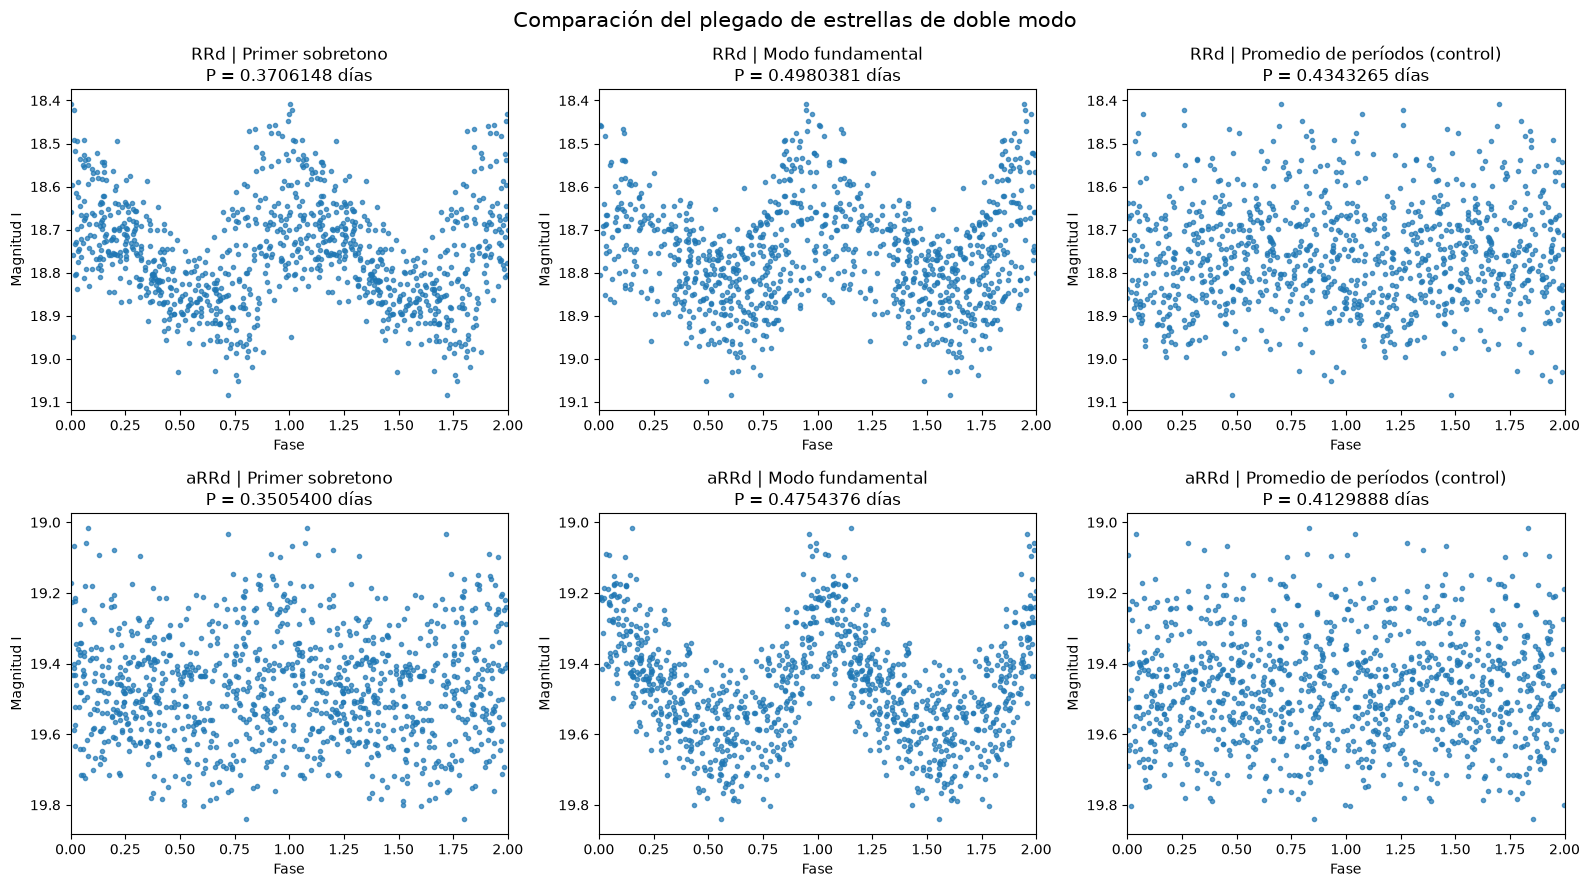

In [5]:
fig, ejes = plt.subplots(2, 3, figsize=(16, 9))

for fila_grafico, (_, estrella) in enumerate(curvas_representativas.iterrows()):

    curva = pd.read_csv(
        Path(estrella["ruta_curva"]),
        sep=r"\s+",
        header=None,
        names=["tiempo", "magnitud", "error"]
    )

    periodo_promedio = (
        estrella["periodo_primer_sobretono"]
        + estrella["periodo_fundamental"]
    ) / 2

    alternativas = [
        (
            "Primer sobretono",
            estrella["periodo_primer_sobretono"],
            estrella["epoca_primer_sobretono"]
        ),
        (
            "Modo fundamental",
            estrella["periodo_fundamental"],
            estrella["epoca_fundamental"]
        ),
        (
            "Promedio de períodos (control)",
            periodo_promedio,
            estrella["epoca_primer_sobretono"]
        )
    ]

    for columna_grafico, (nombre, periodo, epoca) in enumerate(alternativas):

        fase = np.mod(
            (curva["tiempo"].to_numpy() - epoca) / periodo,
            1.0
        )

        magnitud = curva["magnitud"].to_numpy()

        # Duplicación exclusiva para la visualización
        fase_visual = np.concatenate([fase, fase + 1])
        magnitud_visual = np.concatenate([magnitud, magnitud])

        eje = ejes[fila_grafico, columna_grafico]

        eje.scatter(
            fase_visual,
            magnitud_visual,
            s=9,
            alpha=0.7
        )

        eje.set_title(
            f'{estrella["subtipo_rrlyrae"]} | {nombre}\n'
            f'P = {periodo:.7f} días'
        )
        eje.set_xlabel("Fase")
        eje.set_ylabel("Magnitud I")
        eje.set_xlim(0, 2)
        eje.invert_yaxis()

fig.suptitle(
    "Comparación del plegado de estrellas de doble modo",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [6]:
def dispersion_normalizada(tiempo, magnitud, periodo, epoca, n_intervalos=40):
    fase = np.mod((tiempo - epoca) / periodo, 1.0)

    intervalo = np.floor(fase * n_intervalos).astype(int)
    intervalo = np.clip(intervalo, 0, n_intervalos - 1)

    datos = pd.DataFrame({
        "fase": fase,
        "magnitud": magnitud,
        "intervalo": intervalo
    })

    mediana_local = datos.groupby("intervalo")["magnitud"].transform("median")
    residuos = datos["magnitud"] - mediana_local

    dispersion_local = np.sqrt(np.mean(residuos**2))
    dispersion_global = np.std(magnitud, ddof=1)

    return dispersion_local / dispersion_global


resultados_ejemplos = []

for _, estrella in curvas_representativas.iterrows():

    curva = pd.read_csv(
        Path(estrella["ruta_curva"]),
        sep=r"\s+",
        header=None,
        names=["tiempo", "magnitud", "error"]
    )

    tiempo = curva["tiempo"].to_numpy()
    magnitud = curva["magnitud"].to_numpy()

    periodo_promedio = (
        estrella["periodo_primer_sobretono"]
        + estrella["periodo_fundamental"]
    ) / 2

    alternativas = [
        (
            "Primer sobretono",
            estrella["periodo_primer_sobretono"],
            estrella["epoca_primer_sobretono"]
        ),
        (
            "Modo fundamental",
            estrella["periodo_fundamental"],
            estrella["epoca_fundamental"]
        ),
        (
            "Promedio",
            periodo_promedio,
            estrella["epoca_primer_sobretono"]
        )
    ]

    for nombre, periodo, epoca in alternativas:
        resultados_ejemplos.append({
            "observacion_id": estrella["observacion_id"],
            "subtipo": estrella["subtipo_rrlyrae"],
            "alternativa": nombre,
            "dispersion_normalizada": dispersion_normalizada(
                tiempo,
                magnitud,
                periodo,
                epoca
            )
        })

resultados_ejemplos = pd.DataFrame(resultados_ejemplos)

resultados_ejemplos.sort_values(
    ["subtipo", "dispersion_normalizada"]
)

,observacion_id,subtipo,alternativa,dispersion_normalizada
0,OGLEIII_OGLE-LMC-RRLYR-14786,RRd,Primer sobretono,0.777994
1,OGLEIII_OGLE-LMC-RRLYR-14786,RRd,Modo fundamental,0.816374
2,OGLEIII_OGLE-LMC-RRLYR-14786,RRd,Promedio,0.990386
4,OGLEIV_OGLE-SMC-RRLYR-1125,aRRd,Modo fundamental,0.657426
3,OGLEIV_OGLE-SMC-RRLYR-1125,aRRd,Primer sobretono,0.963326
5,OGLEIV_OGLE-SMC-RRLYR-1125,aRRd,Promedio,0.969188


In [7]:
resultados_dispersion = []

total = len(revision_doble_modo)

for numero, (_, estrella) in enumerate(
    revision_doble_modo.iterrows(),
    start=1
):
    curva = pd.read_csv(
        Path(estrella["ruta_curva"]),
        sep=r"\s+",
        header=None,
        names=["tiempo", "magnitud", "error"]
    )

    tiempo = curva["tiempo"].to_numpy()
    magnitud = curva["magnitud"].to_numpy()

    periodo_promedio = (
        estrella["periodo_primer_sobretono"]
        + estrella["periodo_fundamental"]
    ) / 2

    dispersion_sobretono = dispersion_normalizada(
        tiempo,
        magnitud,
        estrella["periodo_primer_sobretono"],
        estrella["epoca_primer_sobretono"]
    )

    dispersion_fundamental = dispersion_normalizada(
        tiempo,
        magnitud,
        estrella["periodo_fundamental"],
        estrella["epoca_fundamental"]
    )

    dispersion_promedio = dispersion_normalizada(
        tiempo,
        magnitud,
        periodo_promedio,
        estrella["epoca_primer_sobretono"]
    )

    dispersion_por_metodo = {
        "Primer sobretono": dispersion_sobretono,
        "Modo fundamental": dispersion_fundamental,
        "Promedio": dispersion_promedio
    }

    resultados_dispersion.append({
        "observacion_id": estrella["observacion_id"],
        "star_id_base": estrella["star_id_base"],
        "subtipo": estrella["subtipo_rrlyrae"],
        "proyecto": estrella["proyecto_origen"],
        "region": estrella["region_origen"],
        "n_obs": estrella["n_obs_validas"],
        "dispersion_primer_sobretono": dispersion_sobretono,
        "dispersion_modo_fundamental": dispersion_fundamental,
        "dispersion_promedio": dispersion_promedio,
        "mejor_plegado": min(
            dispersion_por_metodo,
            key=dispersion_por_metodo.get
        )
    })

    if numero % 500 == 0 or numero == total:
        print(f"{numero:,} de {total:,} curvas procesadas")

resultados_dispersion = pd.DataFrame(resultados_dispersion)

print("\nMejor alternativa por subtipo:")
display(
    pd.crosstab(
        resultados_dispersion["subtipo"],
        resultados_dispersion["mejor_plegado"],
        margins=True
    )
)

print("\nMediana de la dispersión normalizada:")
display(
    resultados_dispersion.groupby("subtipo")[
        [
            "dispersion_primer_sobretono",
            "dispersion_modo_fundamental",
            "dispersion_promedio"
        ]
    ].median()
)

500 de 3,387 curvas procesadas
1,000 de 3,387 curvas procesadas
1,500 de 3,387 curvas procesadas
2,000 de 3,387 curvas procesadas
2,500 de 3,387 curvas procesadas
3,000 de 3,387 curvas procesadas
3,387 de 3,387 curvas procesadas

Mejor alternativa por subtipo:


mejor_plegado,Modo fundamental,Primer sobretono,All
subtipo,,,
RRd,193,3172,3365
aRRd,19,3,22
All,212,3175,3387



Mediana de la dispersión normalizada:


,dispersion_primer_sobretono,dispersion_modo_fundamental,dispersion_promedio
subtipo,,,
RRd,0.687982,0.889516,0.982825
aRRd,0.935254,0.703629,0.987488
